# Satellite Streaks on Legacy Survey Imaging

**Figure layout**
```
[ spectrum shot A ] [ spectrum shot B ] [ spectrum shot C ]   ← full-width top row
[ zoom A (left)  ] [  Legacy Survey grz main panel      ] [ zoom C (right) ]
[ zoom B (left)  ] [  SAT mosaic + IFU footprints       ] [ zoom D (right) ]
```
All streak colours are derived from `satellite_tracks.txt` — one colour per  
unique `(shotid, streak_id)` pair in the field.

In [1]:
#!pip install reproject

## 1 — Imports & configuration

In [8]:
import warnings, os, os.path as op, time, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
import matplotlib.cm as mcm
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter

from astropy.utils.exceptions import AstropyWarning, AstropyUserWarning
from astropy.io.fits.verify import VerifyWarning
warnings.simplefilter('ignore', AstropyWarning)
warnings.simplefilter('ignore', AstropyUserWarning)
warnings.simplefilter('ignore', VerifyWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

from astropy.table import Table
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord, search_around_sky
import astropy.units as u
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from reproject import reproject_interp

# ── Settings ──────────────────────────────────────────────────────────────────
pdr_dir = '/home/jovyan/Hobby-Eberly-Public/HETDEX/pdr/pdr1/'
if not op.exists(pdr_dir):
    pdr_dir = '/home/jovyan/work/pdr1/'

SPEC_FILE    = 'HETDEX_PDR1_satellites.fits'
SAT_BIT      = 1024

# In configuration cell — add alongside SAT_BIT
BAD_BITS = 1 | 2 | 8 | 16   # = 27  (MAIN, FTF, BADPIX, BADAMP)
print(f'Quality mask bits: BAD_BITS = {BAD_BITS} '
      f'(MAIN=1, FTF=2, BADPIX=8, BADAMP=16)')

BAD_SHOTID   = 20200414023
SEARCH_RADIUS = 10 * u.arcmin
PIXSCALE     = 2.0
N_JOBS       = 8
WAVE_MIN = 3500.0
WAVE_MAX = 5500.0
ZOOM_MAX_SEP = 6 * u.arcmin
STAR_RATIO   = 50
OUTPUT_BASE  = 'figures/satellite_streak_figure'

STREAK_PALETTE = [
    '#FFA040',   # 0 orange
    '#40CFFF',   # 1 cyan
    '#59C96A',   # 2 green
    '#4488FF',   # 3 blue
    '#FF6080',   # 4 pink
    '#FFE040',   # 5 yellow
    '#CC88FF',   # 6 purple
]

Quality mask bits: BAD_BITS = 27 (MAIN=1, FTF=2, BADPIX=8, BADAMP=16)


## 2 — Find the densest satellite-streak region

In [3]:
print('Loading ifu-index.fits ...')
ifu_data = Table.read(op.join(pdr_dir, 'ifu-index.fits'))

sat = ifu_data[
    (ifu_data['flag_satellite'] < 0.9) &
    (ifu_data['shotid'] != BAD_SHOTID) &
    ((ifu_data['field'] == 'dex-fall') | (ifu_data['field'] == 'dex-spring'))
]
print(f'  {len(sat)} streak-flagged IFUs (excluding shotid {BAD_SHOTID})')

coords = SkyCoord(ra=sat['ra_cen'], dec=sat['dec_cen'], unit='deg')
idx1, idx2, sep, _ = search_around_sky(coords, coords, SEARCH_RADIUS)
counts = np.bincount(idx1, minlength=len(coords))
order  = np.argsort(-counts)

print('\nTop 10 candidate centres:')
for k in order[:10]:
    print(f'  n={counts[k]:3d}  ra={sat["ra_cen"][k]:9.4f}  '
          f'dec={sat["dec_cen"][k]:+8.4f}  shotid={sat["shotid"][k]}')

Loading ifu-index.fits ...


  1826 streak-flagged IFUs (excluding shotid 20200414023)



Top 10 candidate centres:
  n= 13  ra= 167.3256  dec=+52.8462  shotid=20220402006
  n= 13  ra= 167.3087  dec=+52.8701  shotid=20220402006
  n= 13  ra=  25.0382  dec= -0.2085  shotid=20200118009
  n= 13  ra=  25.0625  dec= -0.2222  shotid=20200118009
  n= 13  ra=  24.9898  dec= -0.1814  shotid=20200118009
  n= 13  ra=  25.0654  dec= -0.1601  shotid=20200118009
  n= 13  ra=  25.0276  dec= -0.1708  shotid=20200118009
  n= 12  ra= 167.5009  dec=+52.9519  shotid=20220402006
  n= 12  ra= 182.4772  dec=+54.2323  shotid=20200617014
  n= 12  ra=  25.1032  dec= -0.1494  shotid=20200118009


In [29]:
best_idx = int(order[7])
ra0  = float(sat['ra_cen'][best_idx])
dec0 = float(sat['dec_cen'][best_idx])

# Manual override — matches the MANUAL_ZOOM shots (20240731006, 20230717010)
ra0, dec0 = 221.596, 49.445

center = SkyCoord(ra=ra0, dec=dec0, unit='deg')
print(f'Region:  RA={ra0:.4f}  Dec={dec0:+.4f}  n={counts[best_idx]}')

Region:  RA=221.5960  Dec=+49.4450  n=12


## 3 — Download Legacy Survey grz cutout

In [30]:
CUTOUT_ARCMIN = SEARCH_RADIUS.value * 2.2
size_pix = int(CUTOUT_ARCMIN * 60 / PIXSCALE)

cache = (f'ls_cutout_{ra0:.4f}_{dec0:+.4f}_'
         f'{CUTOUT_ARCMIN:.1f}arcmin_{PIXSCALE}as.fits')

if not op.exists(cache):
    url = (f'https://www.legacysurvey.org/viewer/fits-cutout'
           f'?ra={ra0}&dec={dec0}&layer=ls-dr9'
           f'&width={size_pix}&height={size_pix}'
           f'&pixscale={PIXSCALE}&bands=grz')
    print(f'Downloading ...\n  {url}')
    sess  = requests.Session()
    retry = Retry(total=5, backoff_factor=2,
                  status_forcelist=[429,500,502,503,504],
                  allowed_methods=['GET'])
    sess.mount('https://', HTTPAdapter(max_retries=retry))
    for attempt in range(3):
        try:
            r = sess.get(url, timeout=300, stream=True)
            r.raise_for_status()
            with open(cache, 'wb') as f:
                for chunk in r.iter_content(1 << 20):
                    f.write(chunk)
            print('  Done.')
            break
        except Exception as e:
            print(f'  Attempt {attempt+1} failed: {e}')
            time.sleep(10)
    else:
        raise RuntimeError('Download failed')
else:
    print(f'Cached: {cache}')

if os.path.getsize(cache) < size_pix * size_pix * 3 * 2:
    os.remove(cache)
    raise RuntimeError('Cached file looks truncated — deleted, please re-run')

hdu_ls   = fits.open(cache)
wcs_ls   = WCS(hdu_ls[0].header).dropaxis(2)
ls_shape = hdu_ls[0].data.shape[1:]
print(f'  Shape: {ls_shape}  '
      f'({ls_shape[1]*PIXSCALE/60:.1f} x {ls_shape[0]*PIXSCALE/60:.1f} arcmin)')

  https://www.legacysurvey.org/viewer/fits-cutout?ra=221.596&dec=49.445&layer=ls-dr9&width=660&height=660&pixscale=2.0&bands=grz


  Done.
  Shape: (660, 660)  (22.0 x 22.0 arcmin)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3353521654762401].


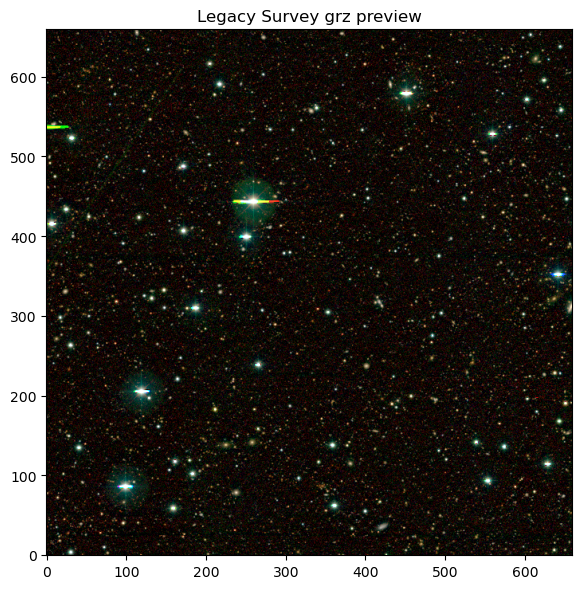

In [31]:
def normalize(data, stretch=1000):
    data = np.clip(data, a_min=0, a_max=None)
    return np.log10(1 + data * stretch) / np.log10(1 + stretch)

rgb = np.stack([
    normalize(hdu_ls[0].data[2]),   # R <- z
    normalize(hdu_ls[0].data[1]),   # G <- r
    normalize(hdu_ls[0].data[0]),   # B <- g
], axis=-1)

fig_p, ax_p = plt.subplots(figsize=(6, 6))
ax_p.imshow(rgb, origin='lower')
ax_p.set_title('Legacy Survey grz preview')
plt.tight_layout(); plt.show()

## 4 — Load satellite track lines & streak spectra

In [11]:
SAT_TRACKS_PATH = 'satellite_tracks.txt'
SAT_TRACKS_URL  = ('https://raw.githubusercontent.com/HETDEX/hetdex_api/'
                   'master/known_issues/hdr3/satellite_tracks.txt')
if not op.exists(SAT_TRACKS_PATH):
    print('Downloading satellite_tracks.txt ...')
    urllib.request.urlretrieve(SAT_TRACKS_URL, SAT_TRACKS_PATH)

sat_tab = Table.read(SAT_TRACKS_PATH, format='ascii',
                     names=['shotid', 'expnum', 'slope', 'intercept'])
sat_tab['shotid'] = sat_tab['shotid'].astype(np.int64)
print(f'Loaded {len(sat_tab)} track rows for '
      f'{len(np.unique(sat_tab["shotid"]))} unique shotids')

# Final publication catalog: HDU 1 = pub table (MRT short column names),
# WAVE/SPECTRA/ERRORS HDUs hold the spectral data arrays.
with fits.open(SPEC_FILE) as spec_hdu:
    index_tbl   = Table(spec_hdu[1].data)
    wave        = spec_hdu['WAVE'].data.astype(float)
    spectra_arr = spec_hdu['SPECTRA'].data.astype(np.float32)
    errors_arr  = spec_hdu['ERRORS'].data.astype(np.float32)

# Rename MRT short column names to the names used by the rest of this notebook
if 'Shot' in index_tbl.colnames:
    index_tbl.rename_column('Shot', 'shotid')
if 'ID' in index_tbl.colnames:
    index_tbl.rename_column('ID', 'streak_id')

nwave = len(wave)
print(f'INDEX: {len(index_tbl)} streaks  |  '
      f'wave: {wave[0]:.0f}-{wave[-1]:.0f} A')

Loaded 546 track rows for 508 unique shotids
INDEX: 527 streaks  |  wave: 3470-5540 A


## 5 — Load & reproject IFU cubes

In [32]:
all_coords = SkyCoord(ra=ifu_data['ra_cen'], dec=ifu_data['dec_cen'], unit='deg')
in_cutout  = center.separation(all_coords) < (CUTOUT_ARCMIN/2 * u.arcmin + 1*u.arcmin)
cubes_in   = ifu_data[in_cutout]
print(f'{len(cubes_in)} IFU cubes in field  '
      f'({(cubes_in["flag_satellite"]<1).sum()} streaked)')

119 IFU cubes in field  (14 streaked)


In [33]:
def load_cube(row):
    shotid  = int(row['shotid'])
    ifuslot = str(row['ifuslot']).strip()
    path = op.join(pdr_dir, 'datacubes', str(shotid),
                   f'dex_cube_{shotid}_{ifuslot}.fits')
    if not op.exists(path):
        return None
    try:
        with fits.open(path, memmap=True) as hdul:
            data = hdul['DATA'].data.astype(np.float32)
            mask = hdul['MASK'].data          # need mask here now too
            hdr  = hdul['DATA'].header
    except Exception:
        return None

    crval = hdr.get('CRVAL3', 3470.0)
    cdelt = hdr.get('CDELT3', hdr.get('CD3_3', 2.0))
    crpix = hdr.get('CRPIX3', 1.0)
    w     = crval + (np.arange(data.shape[0]) + 1 - crpix) * cdelt

    band      = (w >= 3800) & (w <= 5400)
    cube_band = data[band].copy()
    mask_band = mask[band]

    # Zero out channels flagged with any bad quality bit
    bad_channels = (mask_band & BAD_BITS) != 0
    cube_band[bad_channels] = np.nan

    # Keep only SAT-flagged spaxels; blank everything else
    # sat_spaxel = (mask & SAT_BIT).any(axis=0)          # (ny, nx)
    # cube_band[:, ~sat_spaxel] = np.nan

    cube_band[~np.isfinite(cube_band)] = np.nan
    img = np.nansum(cube_band, axis=0)
    # Zero-sum spaxels (all channels masked) → NaN for clean display
    img[img == 0] = np.nan

    wcs2d = WCS(hdr).celestial
    ny, nx = img.shape
    corners = np.array([[0,0],[nx-1,0],[nx-1,ny-1],[0,ny-1],[0,0]])
    cra, cdec = wcs2d.wcs_pix2world(corners[:,0], corners[:,1], 0)

    xpix, ypix = wcs_ls.world_to_pixel_values(cra, cdec)
    x0 = max(0, int(np.floor(xpix.min())) - 2)
    x1 = min(ls_shape[1], int(np.ceil(xpix.max())) + 2)
    y0 = max(0, int(np.floor(ypix.min())) - 2)
    y1 = min(ls_shape[0], int(np.ceil(ypix.max())) + 2)
    if x1 <= x0 or y1 <= y0:
        return None

    sub_wcs = wcs_ls[y0:y1, x0:x1]
    reproj, _ = reproject_interp((img, wcs2d), sub_wcs,
                                  shape_out=(y1-y0, x1-x0),
                                  order='nearest-neighbor')
    x_cen = float(np.mean(wcs_ls.world_to_pixel_values(cra[:-1], cdec[:-1])[0]))

    return dict(
        shotid=shotid, ifuslot=ifuslot,
        flagged=bool(row['flag_satellite'] < 1),
        img=img, wcs2d=wcs2d,
        reproj=reproj.astype(np.float32),
        bbox=(y0, y1, x0, x1),
        footprint=(cra, cdec),
        ra_cen=float(row['ra_cen']),
        dec_cen=float(row['dec_cen']),
        x_cen=x_cen,
        streak_id=-1,
    )


print('Loading cubes ...')
loaded = Parallel(n_jobs=N_JOBS, backend='loky')(
    delayed(load_cube)(row) for row in tqdm(cubes_in)
)
loaded = [d for d in loaded if d is not None]
print(f'Loaded {len(loaded)}  ({sum(d["flagged"] for d in loaded)} streaked)')

Loading cubes ...


  0%|          | 0/119 [00:00<?, ?it/s]

Loaded 118  (14 streaked)


## 6 — Assign streak_id to every flagged IFU using satellite_tracks.txt

In [34]:
def assign_spaxels_to_tracks(spax_ra, spax_dec, track_rows, streak_size=6.0):
    spax_ra  = np.asarray(spax_ra,  dtype=float)
    spax_dec = np.asarray(spax_dec, dtype=float)
    n_spax   = len(spax_ra)
    n_tracks = len(track_rows)
    lim_deg  = streak_size / 3600.0

    dist = np.empty((n_tracks, n_spax), dtype=float)
    for k, row in enumerate(track_rows):
        b = float(row['slope'])
        a = float(row['intercept'])
        dist[k] = np.abs(b * spax_ra - spax_dec + a) / np.sqrt(b**2 + 1.0)

    nearest  = np.argmin(dist, axis=0)
    min_dist = dist[nearest, np.arange(n_spax)]
    return np.where(min_dist <= lim_deg, nearest, -1)


def get_ifu_streak_id(d, sat_tab):
    shotid  = d['shotid']
    ifuslot = d['ifuslot']
    path = op.join(pdr_dir, 'datacubes', str(shotid),
                   f'dex_cube_{shotid}_{ifuslot}.fits')
    if not op.exists(path):
        return -1
    try:
        with fits.open(path, memmap=True) as hdul:
            mask = hdul['MASK'].data
            hdr  = hdul['DATA'].header
    except Exception:
        return -1

    sat_spaxel = (mask & SAT_BIT).any(axis=0)
    if not sat_spaxel.any():
        return -1

    yy, xx = np.where(sat_spaxel)
    wcs2d  = WCS(hdr).celestial
    spax_ra, spax_dec = wcs2d.wcs_pix2world(xx.astype(float), yy.astype(float), 0)

    track_rows = list(sat_tab[sat_tab['shotid'] == shotid])
    if not track_rows:
        return -1

    labels = assign_spaxels_to_tracks(spax_ra, spax_dec, track_rows)
    valid  = labels[labels >= 0]
    if len(valid) == 0:
        return -1
    vals, cnts = np.unique(valid, return_counts=True)
    return int(vals[np.argmax(cnts)])


print('Assigning streak IDs to all flagged IFUs ...')
for d in tqdm([x for x in loaded if x['flagged']], desc='streak IDs'):
    d['streak_id'] = get_ifu_streak_id(d, sat_tab)

streak_keys = sorted(set(
    (d['shotid'], d['streak_id'])
    for d in loaded
    if d['flagged'] and d['streak_id'] >= 0
))
print(f'\nFound {len(streak_keys)} distinct streaks in field:')
for sk in streak_keys:
    print(f'  shotid={sk[0]}  streak_id={sk[1]}')

streak_color_map = {
    sk: STREAK_PALETTE[i % len(STREAK_PALETTE)]
    for i, sk in enumerate(streak_keys)
}
print('\nColour assignments:')
for sk, col in streak_color_map.items():
    print(f'  shotid={sk[0]}  streak_id={sk[1]}  ->  {col}')


def ifu_color(d):
    if not d['flagged']:
        return 'white'
    key = (d['shotid'], d.get('streak_id', -1))
    return streak_color_map.get(key, '#FF4444')

Assigning streak IDs to all flagged IFUs ...


streak IDs:   0%|          | 0/14 [00:00<?, ?it/s]


Found 3 distinct streaks in field:
  shotid=20230717010  streak_id=0
  shotid=20240731006  streak_id=0
  shotid=20240731006  streak_id=1

Colour assignments:
  shotid=20230717010  streak_id=0  ->  #FFA040
  shotid=20240731006  streak_id=0  ->  #40CFFF
  shotid=20240731006  streak_id=1  ->  #59C96A


## 7 — Choose 4 zoom IFUs

In [35]:
shotids_with_spectra = set(index_tbl['shotid'].astype(int))

def has_star(d):
    img   = d['img']
    valid = img[np.isfinite(img) & (img > 0)]
    if valid.size == 0:
        return False
    return float(np.percentile(valid, 98)) > STAR_RATIO * float(np.median(valid))

def streak_score(d):
    img   = d['reproj']
    valid = np.isfinite(img) & (img > 0)
    if valid.sum() == 0:
        return 0.0
    return float(np.nanpercentile(img[valid], 99)) * valid.mean()

cx_field   = ls_shape[1] / 2.0
candidates = [
    d for d in loaded
    if d['flagged']
    and d['shotid'] != BAD_SHOTID
    and d['shotid'] in shotids_with_spectra
    and center.separation(SkyCoord(d['ra_cen'], d['dec_cen'], unit='deg')) < ZOOM_MAX_SEP
    and not has_star(d)
]
print(f'{len(candidates)} candidate IFUs')

left_cands  = [d for d in candidates if d['x_cen'] <= cx_field]
right_cands = [d for d in candidates if d['x_cen'] >  cx_field]
print(f'  {len(left_cands)} left  /  {len(right_cands)} right')

def pick_two(pool, sep_min=1.5 * u.arcmin):
    if not pool:
        return []
    pool = sorted(pool, key=streak_score, reverse=True)
    chosen = [pool[0]]
    for cand in pool[1:]:
        c = SkyCoord(cand['ra_cen'], cand['dec_cen'], unit='deg')
        seps = [c.separation(SkyCoord(z['ra_cen'], z['dec_cen'], unit='deg'))
                for z in chosen]
        if min(seps) > sep_min:
            chosen.append(cand)
        if len(chosen) >= 2:
            break
    return chosen

zoom_cubes = pick_two(left_cands) + pick_two(right_cands)
print('Auto-selected:')
for i, d in enumerate(zoom_cubes):
    side = 'LEFT ' if i < 2 else 'RIGHT'
    print(f'  {side}  {d["shotid"]} / {d["ifuslot"]}  '
          f'streak_id={d["streak_id"]}  colour={ifu_color(d)}')

8 candidate IFUs
  4 left  /  4 right
Auto-selected:
  LEFT   20240731006 / 074  streak_id=0  colour=#40CFFF
  LEFT   20240731006 / 084  streak_id=0  colour=#40CFFF
  RIGHT  20230717010 / 039  streak_id=0  colour=#FFA040
  RIGHT  20240731006 / 033  streak_id=1  colour=#59C96A


In [36]:
# ── Manual override ───────────────────────────────────────────────────────────
# Set MANUAL_ZOOM to a list of (shotid, ifuslot) tuples to pin specific IFUs,
# or leave empty to use the auto-selection from the cell above.
# NOTE: these shotids must be in the currently loaded field.
MANUAL_ZOOM = [
    (20240731006, '094'),   # left A
    (20240731006, '014'),   # left B
    (20230717010, '039'),   # right C
    (20240731006, '033'),   # right D
]

if MANUAL_ZOOM:
    manual_cubes = []
    for shotid, ifuslot in MANUAL_ZOOM:
        match = [d for d in loaded
                 if d['shotid'] == shotid and d['ifuslot'] == ifuslot]
        if match:
            manual_cubes.append(match[0])
        else:
            print(f'WARNING: {shotid}/{ifuslot} not found in loaded field')
    if manual_cubes:
        zoom_cubes = manual_cubes
        print(f'Manual selection: {len(zoom_cubes)} IFUs')
    else:
        print('No manual IFUs found — keeping auto-selection')
else:
    print('No manual override — using auto-selected zoom_cubes')

zoom_colors = [ifu_color(d) for d in zoom_cubes]
print(f'Zoom IFUs ({len(zoom_cubes)}):')
for d, col in zip(zoom_cubes, zoom_colors):
    print(f'  {d["shotid"]} / {d["ifuslot"]}  streak_id={d["streak_id"]}  colour={col}')

Manual selection: 4 IFUs
Zoom IFUs (4):
  20240731006 / 094  streak_id=0  colour=#40CFFF
  20240731006 / 014  streak_id=1  colour=#59C96A
  20230717010 / 039  streak_id=0  colour=#FFA040
  20240731006 / 033  streak_id=1  colour=#59C96A


## 8 — Fetch spectra for the zoom shots

In [37]:
def get_shot_spectrum(shotid):
    """Return list of (wave, flux, err, label) ordered by streak_id."""
    mask = index_tbl['shotid'].astype(int) == int(shotid)
    rows = np.where(mask)[0]
    if len(rows) == 0:
        return []
    results = []
    for local_i, row_idx in enumerate(sorted(rows, key=lambda r: index_tbl['streak_id'][r])):
        streak_id = int(index_tbl['streak_id'][row_idx])
        n_spax = int(index_tbl['n_spax'][row_idx]) if 'n_spax' in index_tbl.colnames else (
                 int(index_tbl['NSpax'][row_idx]) if 'NSpax' in index_tbl.colnames else 0)
        label = (f'shotid {shotid}  streak {local_i}'
                 + (f'  ({n_spax} spaxels)' if n_spax else ''))
        results.append((wave, spectra_arr[row_idx], errors_arr[row_idx], label))
    return results


def streak_colors_for_shot(shotid):
    """Return ordered colour list matching get_shot_spectrum() order.

    streak_color_map is keyed by (shotid, local_track_id) where local_track_id
    is the 0-based per-shot index from satellite_tracks.txt.  The pub catalog
    column 'streak_id' is a global index (0-526), not the local track id, so
    we use the enumeration position instead.
    """
    mask = index_tbl['shotid'].astype(int) == int(shotid)
    rows = np.where(mask)[0]
    colors = []
    for local_i, row_idx in enumerate(sorted(rows, key=lambda r: index_tbl['streak_id'][r])):
        key = (int(shotid), local_i)
        colors.append(streak_color_map.get(key, STREAK_PALETTE[local_i % len(STREAK_PALETTE)]))
    return colors


# Collect unique shots from zoom_cubes, preserving order
seen_shots = {}
spec_entries = []   # list of (shotid, sp_list, colors)
for d in zoom_cubes:
    sid = d['shotid']
    if sid not in seen_shots:
        seen_shots[sid] = True
        spec_entries.append((
            sid,
            get_shot_spectrum(sid),
            streak_colors_for_shot(sid),
        ))

print(f'{len(spec_entries)} unique shots for spectrum panels:')
for sid, sp, cols in spec_entries:
    print(f'  shotid={sid}  {len(sp)} streak(s)  colours={cols}')

2 unique shots for spectrum panels:
  shotid=20240731006  2 streak(s)  colours=['#40CFFF', '#59C96A']
  shotid=20230717010  1 streak(s)  colours=['#FFA040']


## 9 — Load SAT-only mosaic

In [38]:
streaked_in_field = [d for d in loaded if d['flagged']]

def load_sat_image(row):
    shotid  = int(row['shotid'])
    ifuslot = str(row['ifuslot']).strip()
    path = op.join(pdr_dir, 'datacubes', str(shotid),
                   f'dex_cube_{shotid}_{ifuslot}.fits')
    if not op.exists(path):
        return None
    try:
        with fits.open(path, memmap=True) as hdul:
            data = hdul['DATA'].data.astype(np.float32)
            mask = hdul['MASK'].data
            hdr  = hdul['DATA'].header
    except Exception:
        return None

    crval = hdr.get('CRVAL3', 3470.0)
    cdelt = hdr.get('CDELT3', hdr.get('CD3_3', 2.0))
    crpix = hdr.get('CRPIX3', 1.0)
    w     = crval + (np.arange(data.shape[0]) + 1 - crpix) * cdelt
    band  = (w >= WAVE_MIN) & (w <= WAVE_MAX)

    sat_spaxel = (mask & SAT_BIT).any(axis=0)
    if not sat_spaxel.any():
        return None

    cube_band = data[band].copy()
    cube_band[~np.isfinite(cube_band)] = np.nan
    img = np.nansum(cube_band, axis=0).astype(np.float32)
    img[~sat_spaxel] = np.nan

    wcs2d = WCS(hdr).celestial
    ny, nx = img.shape
    corners = np.array([[0,0],[nx-1,0],[nx-1,ny-1],[0,ny-1],[0,0]])
    cra, cdec = wcs2d.wcs_pix2world(corners[:,0], corners[:,1], 0)

    xpix, ypix = wcs_ls.world_to_pixel_values(cra, cdec)
    x0 = max(0, int(np.floor(xpix.min())) - 2)
    x1 = min(ls_shape[1], int(np.ceil(xpix.max())) + 2)
    y0 = max(0, int(np.floor(ypix.min())) - 2)
    y1 = min(ls_shape[0], int(np.ceil(ypix.max())) + 2)
    if x1 <= x0 or y1 <= y0:
        return None

    sub_wcs = wcs_ls[y0:y1, x0:x1]
    reproj, _ = reproject_interp((img, wcs2d), sub_wcs,
                                  shape_out=(y1-y0, x1-x0),
                                  order='nearest-neighbor')
    reproj = reproj.astype(np.float32)
    reproj[reproj == 0] = np.nan
    return dict(reproj=reproj, bbox=(y0, y1, x0, x1))


print(f'Loading SAT images for {len(streaked_in_field)} IFUs ...')
sat_images = []
for d in tqdm(streaked_in_field, desc='SAT images'):
    match = cubes_in[
        (cubes_in['shotid'] == d['shotid']) &
        (np.array([s.strip() for s in cubes_in['ifuslot']]) == d['ifuslot'])
    ]
    if len(match) == 0:
        continue
    result = load_sat_image(match[0])
    if result is not None:
        sat_images.append(result)
print(f'  Loaded {len(sat_images)} SAT streak images')

sat_mosaic = np.full(ls_shape, np.nan, dtype=np.float32)
for s in sat_images:
    y0, y1, x0, x1 = s['bbox']
    tile     = s['reproj']
    m        = np.isfinite(tile)
    existing = sat_mosaic[y0:y1, x0:x1]
    sat_mosaic[y0:y1, x0:x1] = np.where(
        m & (np.isnan(existing) | (tile > existing)), tile, existing
    )

Loading SAT images for 14 IFUs ...


SAT images:   0%|          | 0/14 [00:00<?, ?it/s]

  Loaded 14 SAT streak images


## 10 — Build the figure

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3353521654762401].


/tmp/ipykernel_1523655/916733000.py:171: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_sat = mcm.get_cmap('Greys_r').copy()


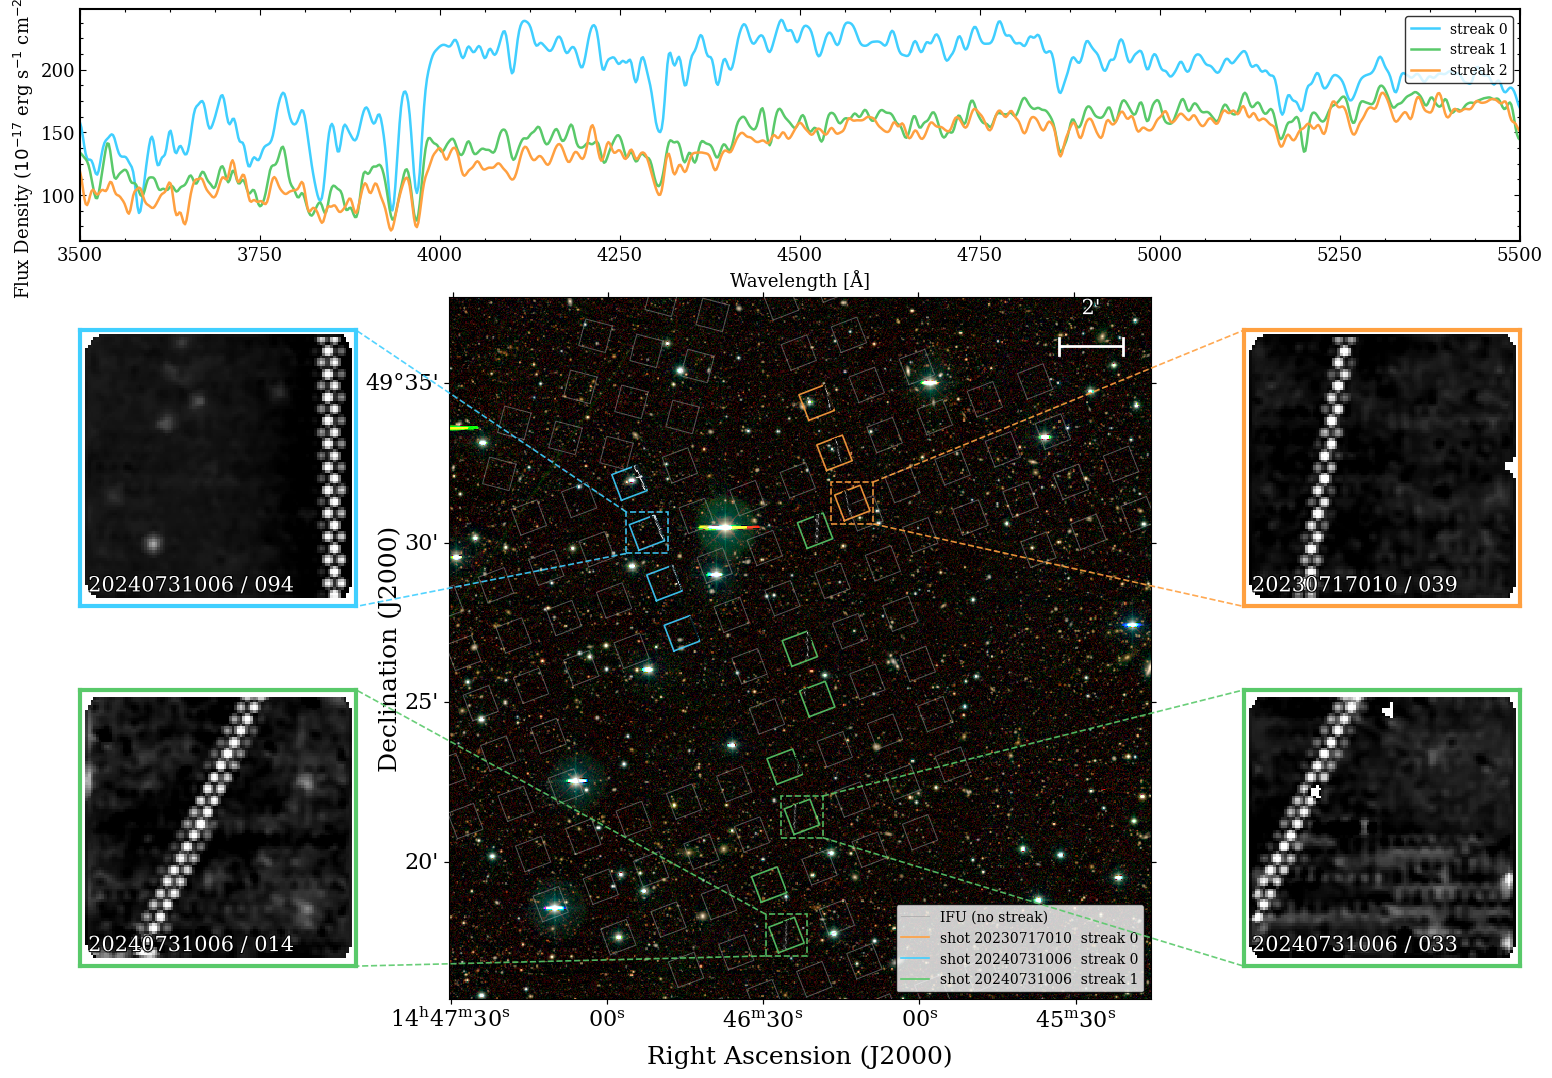

In [58]:
# ── Font & style constants ─────────────────────────────────────────────────────
FS_LABEL  = 18   # axis labels (main panel, zoom annotations)
FS_SPEC   = 13   # spectrum panel axis labels & ticks (smaller — long ylabel)
FS_TICK   = 16   # tick-label numbers (main panel)
FS_LEGEND = 10   # legend entries
FS_ANNOT  = 15   # in-panel text annotations (IFU ids, scale bar)
SPINE_LW  =  1.5 # spine linewidth for spectrum + main panels
SPEC_LW   =  1.8 # spectrum line width
ZOOM_BDR  =  3.0 # zoom inset border linewidth

plt.rcParams.update({
    'font.family' : 'serif',
    'font.size'   : FS_LABEL,
    'text.color'  : 'black',
    'axes.labelcolor': 'black',
    'xtick.color' : 'black',
    'ytick.color' : 'black',
})

# ── Plot helpers ───────────────────────────────────────────────────────────────

def footprint_pix_bbox(d):
    cra, cdec = d['footprint']
    xp, yp = wcs_ls.world_to_pixel_values(cra[:-1], cdec[:-1])
    return xp.min(), xp.max(), yp.min(), yp.max()


def plot_spectrum(ax, sp_list, colors, title='', show_ylabel=True):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(SPINE_LW)
    ax.tick_params(which='both', colors='black', labelsize=FS_SPEC,
                   direction='in', top=True, right=True,
                   length=4, width=0.8)
    ax.tick_params(which='minor', length=2)
    from matplotlib.ticker import AutoMinorLocator
    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))

    if not sp_list:
        ax.text(0.5, 0.5, 'no spectrum', transform=ax.transAxes,
                color='grey', ha='center', va='center', fontsize=FS_SPEC)
        return

    for i, (w, flux, err, label) in enumerate(sp_list):
        col   = colors[i % len(colors)]
        wband = (w >= WAVE_MIN) & (w <= WAVE_MAX)
        w_p   = w[wband]
        f_p   = gaussian_filter(np.nan_to_num(flux[wband], nan=0.0), sigma=2)
        ax.plot(w_p, f_p, color=col, lw=SPEC_LW, label=f'streak {i}')

    ax.set_xlim(WAVE_MIN, WAVE_MAX)
    ax.autoscale(axis='y')
    ax.set_xlabel('Wavelength [Å]', fontsize=FS_SPEC, color='black')
    if show_ylabel:
        ax.set_ylabel(
            r'Flux Density ($10^{-17}$ erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)',
            fontsize=FS_SPEC, color='black')
    if title:
        ax.set_title(title, fontsize=FS_SPEC, color='black', pad=3)
    if len(sp_list) > 1:
        ax.legend(fontsize=FS_LEGEND, framealpha=0.8, facecolor='white',
                  labelcolor='black', edgecolor='black', loc='upper right')


def plot_ifu_zoom(ax, d, border_color):
    img = d['img'].copy()
    img[~np.isfinite(img)] = np.nan
    if np.isfinite(img).any():
        bg       = gaussian_filter(np.nan_to_num(img, nan=0.0),
                                   sigma=max(img.shape) // 6)
        img_disp = img - bg
    else:
        img_disp = img
    vmin = np.nanpercentile(img_disp, 10)
    vmax = np.nanpercentile(img_disp, 99.5)
    ax.set_facecolor('white')
    ax.imshow(img_disp, origin='lower', cmap='Greys_r',
              vmin=vmin, vmax=vmax, interpolation='nearest', aspect='equal')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(ZOOM_BDR)
    ax.text(0.03, 0.04, f'{d["shotid"]} / {d["ifuslot"]}',
            transform=ax.transAxes, color='white', fontsize=FS_ANNOT,
            va='bottom', ha='left',
            path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])


# ── Figure layout ──────────────────────────────────────────────────────────────
SPEC_H = 0.33
ZOOM_H = 1.0

fig = plt.figure(figsize=(16, 11), facecolor='white')

gs_rows = gridspec.GridSpec(
    2, 3,
    height_ratios=[SPEC_H, 1.0],
    width_ratios=[1, 2.6, 1],
    hspace=0.12, wspace=0.2,
    left=0.07, right=0.97, top=0.95, bottom=0.05,
)

ax_sp = fig.add_subplot(gs_rows[0, :])

all_sp   = [item for _, sp, _    in spec_entries for item in sp]
all_cols = [col  for _, _,  cols in spec_entries for col  in cols]

gs_left  = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=gs_rows[1, 0],
    height_ratios=[ZOOM_H, ZOOM_H], hspace=0.05,
)
gs_right = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=gs_rows[1, 2],
    height_ratios=[ZOOM_H, ZOOM_H], hspace=0.05,
)

# ── Spectrum panel ─────────────────────────────────────────────────────────────
plot_spectrum(ax_sp, all_sp, all_cols, show_ylabel=True)

# ── Main panel ─────────────────────────────────────────────────────────────────
ax_main = fig.add_subplot(gs_rows[1, 1], projection=wcs_ls)
ax_main.imshow(rgb, origin='lower', interpolation='nearest')
ax_main.set_facecolor('white')

for d in loaded:
    cra, cdec = d['footprint']
    if d['flagged']:
        clr, lw, alpha, zo = ifu_color(d), 1.2, 0.9, 3
    else:
        clr, lw, alpha, zo = '#aaaaaa', 0.7, 0.5, 2
    ax_main.plot(cra, cdec, color=clr, lw=lw, alpha=alpha, zorder=zo,
                 transform=ax_main.get_transform('world'))

ax_main.set_xlabel('Right Ascension (J2000)', fontsize=FS_LABEL, color='black')
ax_main.coords[1].set_axislabel('Declination (J2000)', color='black',
                                 fontsize=FS_LABEL, minpad=-1)
ax_main.coords[0].set_major_formatter('hh:mm:ss')
ax_main.coords[1].set_major_formatter('dd:mm')
ax_main.coords[0].set_ticks(color='black')
ax_main.coords[0].set_ticklabel(color='black', size=FS_TICK)
ax_main.coords[1].set_ticks(color='black')
ax_main.coords[1].set_ticklabel(color='black', size=FS_TICK)
for spine in ax_main.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(SPINE_LW)

zoom = 1.0
ny, nx = ls_shape
cx, cy = nx / 2, ny / 2
ax_main.set_xlim(cx - nx/(2*zoom), cx + nx/(2*zoom))
ax_main.set_ylim(cy - ny/(2*zoom), cy + ny/(2*zoom))

legend_els = [Line2D([0],[0], color='#aaaaaa', lw=0.7, alpha=0.8,
                     label='IFU (no streak)')]
for sk, col in streak_color_map.items():
    legend_els.append(
        Line2D([0],[0], color=col, lw=1.2,
               label=f'shot {sk[0]}  streak {sk[1]}')
    )
ax_main.legend(handles=legend_els, loc='lower right', fontsize=FS_LEGEND,
               framealpha=0.8, facecolor='white', labelcolor='black',
               edgecolor='black')

# ── SAT mosaic overplot ────────────────────────────────────────────────────────
finite = sat_mosaic[np.isfinite(sat_mosaic)]
if finite.size > 0:
    vmin_sat = np.percentile(finite, 10)
    vmax_sat = np.percentile(finite, 99)
    cmap_sat = mcm.get_cmap('Greys_r').copy()
    cmap_sat.set_bad(alpha=0)
    ax_main.imshow(sat_mosaic,
                   origin='lower', cmap=cmap_sat,
                   vmin=vmin_sat, vmax=vmax_sat,
                   alpha=0.85, interpolation='nearest',
                   transform=ax_main.get_transform('pixel'),
                   zorder=5,
                   extent=[0, ls_shape[1], 0, ls_shape[0]])

# ── Zoom panels + colour-coded dashed boxes ────────────────────────────────────
BOX_PAD = 3
LW, LS, LA = 1.2, '--', 0.9

zoom_axes   = []
zoom_bboxes = []

for i, d in enumerate(zoom_cubes):
    col     = zoom_colors[i]
    on_left = (i < 2)
    gs_side = gs_left if on_left else gs_right
    row_idx = i % 2

    ax_z = fig.add_subplot(gs_side[row_idx, 0])
    plot_ifu_zoom(ax_z, d, border_color=col)
    zoom_axes.append(ax_z)

    fx0, fx1, fy0, fy1 = footprint_pix_bbox(d)
    zoom_bboxes.append((fx0, fx1, fy0, fy1))
    rect = mpatches.Rectangle(
        (fx0-BOX_PAD, fy0-BOX_PAD),
        (fx1-fx0)+2*BOX_PAD, (fy1-fy0)+2*BOX_PAD,
        lw=LW, edgecolor=col, ls=LS, facecolor='none',
        alpha=LA, zorder=6,
        transform=ax_main.get_transform('pixel'),
    )
    ax_main.add_patch(rect)

# ── Scale bar ──────────────────────────────────────────────────────────────────
fig.canvas.draw()

SCALEBAR_ARCMIN = 2.0
scalebar_pix = SCALEBAR_ARCMIN * 60 / PIXSCALE
xlo, xhi = ax_main.get_xlim()
ylo, yhi = ax_main.get_ylim()
x_end   = xhi - (xhi - xlo) * 0.04
x_start = x_end - scalebar_pix
y_bar   = yhi - (yhi - ylo) * 0.07
y_text  = yhi - (yhi - ylo) * 0.03
tick_h  = (yhi - ylo) * 0.012
ax_main.plot([x_start, x_end], [y_bar, y_bar],
             color='white', lw=2.0, solid_capstyle='butt',
             transform=ax_main.get_transform('pixel'), zorder=8)
for x in [x_start, x_end]:
    ax_main.plot([x, x], [y_bar-tick_h, y_bar+tick_h],
                 color='white', lw=2.0,
                 transform=ax_main.get_transform('pixel'), zorder=8)
ax_main.text((x_start+x_end)/2, y_text, f"{SCALEBAR_ARCMIN:.0f}'",
             color='white', fontsize=FS_ANNOT, ha='center', va='bottom',
             transform=ax_main.get_transform('pixel'), zorder=8,
             path_effects=[pe.withStroke(linewidth=2, foreground='black')])

# ── Colour-coded connector lines ───────────────────────────────────────────────
def ax_frac_to_fig(ax, xf, yf):
    return fig.transFigure.inverted().transform(
        ax.transAxes.transform((xf, yf)))

def main_pix_to_fig(xp, yp):
    return fig.transFigure.inverted().transform(
        ax_main.transData.transform((xp, yp)))

for i, (d, ax_z, (fx0, fx1, fy0, fy1)) in enumerate(
        zip(zoom_cubes, zoom_axes, zoom_bboxes)):
    col      = zoom_colors[i]
    bx0, bx1 = fx0-BOX_PAD, fx1+BOX_PAD
    by0, by1 = fy0-BOX_PAD, fy1+BOX_PAD
    on_left  = (i < 2)
    if on_left:
        box_top  = main_pix_to_fig(bx0, by1)
        box_bot  = main_pix_to_fig(bx0, by0)
        zoom_top = ax_frac_to_fig(ax_z, 1.0, 1.0)
        zoom_bot = ax_frac_to_fig(ax_z, 1.0, 0.0)
    else:
        box_top  = main_pix_to_fig(bx1, by1)
        box_bot  = main_pix_to_fig(bx1, by0)
        zoom_top = ax_frac_to_fig(ax_z, 0.0, 1.0)
        zoom_bot = ax_frac_to_fig(ax_z, 0.0, 0.0)
    for p1, p2 in [(box_top, zoom_top), (box_bot, zoom_bot)]:
        fig.add_artist(plt.Line2D(
            [p1[0], p2[0]], [p1[1], p2[1]],
            transform=fig.transFigure,
            color=col, lw=LW, ls=LS, alpha=LA,
            clip_on=False, zorder=10,
        ))

plt.show()

## 11 — Save

In [59]:
for ext in ('pdf', 'png'):
    fname = f'{OUTPUT_BASE}.{ext}'
    fig.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'Saved  {fname}')

Saved  figures/satellite_streak_figure.pdf


Saved  figures/satellite_streak_figure.png
